# 02 — Quantisation Study (THE SPINE)

*Part of **Gamaka Floor** — a raga pitch-contour study.*

Measures how raga classifiability decays as pitch resolution is coarsened from
near-continuous cents down to semitone (12-tone) quantisation. This is the
project's headline result. See `CLAUDE.md` for the decisions this notebook encodes
and `status/STATUS_M2.md` for the write-up.

Runs the sweep on **both** corpora and **multiple raga pools**, per the owner's
scope decision:
- **alapana-only** corpus (4 ragas, unmetered) — recording-grouped.
- **all-vocal-sections** corpus, **primary pool** (12 ragas: ≥3 recordings, ≥3
  artists, ≥3 compositions) — recording-, artist-, AND composition-grouped, to show
  the result survives every confound-control scheme, not just one.
- **all-vocal-sections** corpus, **secondary/full pool** (ragas with ≥2 recordings,
  ≥2 artists) — recording-grouped, as a broad robustness check.

Also produces the **per-raga degradation ranking** (continuous → semitone accuracy
drop, one number per raga) that generalises the allied-pair claim independent of
whatever the owner decides on that front.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd())
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
import dgm_utils as U

BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=="notebooks" else os.getcwd()
ART = os.path.join(BASE, "artifacts")
CORPUS_ALAP = os.path.join(BASE, "corpus")
CORPUS_ALL  = os.path.join(BASE, "corpus_allsections")
os.makedirs(os.path.join(ART, "figures"), exist_ok=True)
pd.set_option("display.width", 180); pd.set_option("display.max_rows", 300)

# --- params (spec: "make it a param") ---
WINDOW_SEC = 4.0
HOP_SEC = 4.0
RESOLUTIONS = U.RESOLUTIONS_CENTS  # [10, 20, 50, 100] cents; 10c stands in for "continuous"
CLF_KW = dict(max_iter=1000, class_weight="balanced", C=10)  # see section 2 for why
print(f"window={WINDOW_SEC}s hop={HOP_SEC}s resolutions={RESOLUTIONS}c")

window=4.0s hop=4.0s resolutions=[10, 20, 50, 100]c


## 1. Build window tables

Each corpus segment (already unfolded, cleaned cents) is folded once, then cut into
fixed-length windows. fps is recovered exactly from the manifest's stored
`minutes` and the `.npy` frame count (M1 already showed fps differs between
`pitch.txt` and `pitch-vocal.txt` sources; this avoids re-deriving or assuming it).

In [2]:
def build_windows_table(corpus_dir, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    mf = pd.read_csv(os.path.join(corpus_dir, "manifest.csv"), encoding="utf-8")
    rows, n_too_short = [], 0
    for _, r in mf.iterrows():
        arr = np.load(os.path.join(corpus_dir, r.file))
        fps = U.recover_fps(len(arr), r.minutes)
        folded = U.fold_cents(arr)
        win_frames, hop_frames = int(round(window_sec*fps)), int(round(hop_sec*fps))
        wins = U.make_windows(folded, win_frames, hop_frames)
        if not wins:
            n_too_short += 1
            continue
        for w in wins:
            rows.append(dict(raga=r.raga, artist=r.artist,
                             composition_id=r.get("composition_id"),
                             recording=r.recording, window=w))
    print(f"[{os.path.basename(corpus_dir)}] segments too short for one window: {n_too_short}/{len(mf)}")
    return pd.DataFrame(rows)

W_ALAP = build_windows_table(CORPUS_ALAP)
W_ALL = build_windows_table(CORPUS_ALL)
print(f"\nalapana windows: {len(W_ALAP)}   allsections windows: {len(W_ALL)}")
print("\nwindows per raga (alapana):"); print(W_ALAP.groupby("raga").size().to_string())
print("\nwindows per raga (allsections, top 15):")
print(W_ALL.groupby("raga").size().sort_values(ascending=False).head(15).to_string())

[corpus] segments too short for one window: 0/8


[corpus_allsections] segments too short for one window: 0/526

alapana windows: 1012   allsections windows: 23449

windows per raga (alapana):
raga
Bhairavi         188
Karaharapriya    362
Mōhanaṁ          276
Ṣanmukhapriya    186

windows per raga (allsections, top 15):
raga
Tōḍi             1727
Ṣanmukhapriya    1621
Bhairavi         1606
Kāṁbhōji         1225
Karaharapriya    1033
Mōhanaṁ           872
Kamās             736
Rītigauḷa         698
Harikāmbhōji      643
Bēgaḍa            634
Nāṭakapriya       555
Sāvēri            499
Kēdāragauḷa       495
Kalyāṇi           494
Kāpi              486


## 2. Classifier config -- a class-imbalance catch worth keeping visible

Window counts per raga range from ~170 to ~1700 (allsections corpus). Plain
multinomial logistic regression collapses under this imbalance: several ragas get
**0% recall at every resolution**, balanced accuracy sits near chance, and the
resolution sweep is non-monotonic noise -- not because the hypothesis is wrong, but
because the classifier never learns the rare classes at all. `class_weight="balanced"`
fixes this outright (demonstrated below on the small alapana corpus, where the
before/after is stark). `C=10` (less L2 regularization than sklearn's default) gave
a cleaner, higher-accuracy curve in validation without reintroducing the
zero-recall problem -- kept as the standard config for every experiment in this
notebook.

In [3]:
from sklearn.model_selection import cross_val_predict

y_demo = W_ALAP.raga.values
groups_demo = W_ALAP.recording.values
splitter_demo, ns_demo = U.make_group_cv(y_demo, groups_demo, max_splits=5)
X_demo = np.stack([U.histogram_feature(w, 20) for w in W_ALAP.window])

for label, kw in [("unweighted (default)", dict(max_iter=1000)),
                  ("class_weight=balanced, C=10 (chosen)", CLF_KW)]:
    pred = cross_val_predict(LogisticRegression(**kw), X_demo, y_demo,
                             cv=splitter_demo.split(X_demo, y_demo, groups_demo), n_jobs=1)
    n_zero = sum(1 for c in np.unique(y_demo) if (pred[y_demo==c]==c).mean()==0)
    print(f"{label:38s}  bal_acc={balanced_accuracy_score(y_demo,pred):.3f}  "
          f"zero_recall_classes={n_zero}/{len(np.unique(y_demo))}")

unweighted (default)                    bal_acc=0.226  zero_recall_classes=0/4
class_weight=balanced, C=10 (chosen)    bal_acc=0.501  zero_recall_classes=0/4


## 3. Raga pools

In [4]:
cov = pd.read_csv(os.path.join(ART, "coverage_allsections.csv"), encoding="utf-8")
PRIMARY_POOL = cov.query("recs>=3 and artists>=3 and comps>=3").raga.tolist()
SECONDARY_POOL = cov.query("recs>=2 and artists>=2").raga.tolist()
ALAPANA_RAGAS = sorted(W_ALAP.raga.unique().tolist())
print(f"alapana pool ({len(ALAPANA_RAGAS)}): {ALAPANA_RAGAS}")
print(f"primary pool ({len(PRIMARY_POOL)}): {PRIMARY_POOL}")
print(f"secondary pool ({len(SECONDARY_POOL)}): {SECONDARY_POOL}")

alapana pool (4): ['Bhairavi', 'Karaharapriya', 'Mōhanaṁ', 'Ṣanmukhapriya']
primary pool (12): ['Kamās', 'Tōḍi', 'Bhairavi', 'Behāg', 'Kalyāṇi', 'Mōhanaṁ', 'Suraṭi', 'Rītigauḷa', 'Ṣanmukhapriya', 'Harikāmbhōji', 'Sindhubhairavi', 'Sāvēri']
secondary pool (40): ['Kamās', 'Saurāṣtraṁ', 'Tōḍi', 'Bhairavi', 'Behāg', 'Kalyāṇi', 'Mōhanaṁ', 'Suraṭi', 'Rītigauḷa', 'Ṣanmukhapriya', 'Kāṁbhōji', 'Kānaḍa', 'Harikāmbhōji', 'Jōnpuri', 'Sindhubhairavi', 'Sāvēri', 'Śankarābharaṇaṁ', 'Karaharapriya', 'Kuntalavarāḷi', 'Kumudakriyā', 'Kēdāragauḷa', 'Amṛtavarṣiṇi', 'Kalgaḍa', 'Hamīr kaḷyaṇi', 'Gauḷa', 'Jaganmōhini', 'Bēgaḍa', 'Pūrṇacandrika', 'Nīlāṁbari', 'Pāḍi', 'Madhyamāvati', 'Lalita', 'Maṇirangu', 'Nāṭa', 'Nādanāmakriya', 'Śrīranjani', 'Śuddadhanyāsi', 'Ābhōgi', 'Mārgahindōḷaṁ', 'Karṇāṭaka dēvagāndhāri']


## 4. The resolution sweep

Per-fold results (not just the mean) are kept, so error bars over folds are real and
per-fold numbers can be saved (spec acceptance: "per-fold numbers saved").

In [5]:
def run_cv_perfold(dfw, group_col, resolutions=RESOLUTIONS, max_splits=5):
    y = dfw.raga.values
    groups = dfw[group_col].values
    splitter, n_splits = U.make_group_cv(y, groups, max_splits=max_splits)
    fold_ids = np.zeros(len(y), dtype=int)
    for i, (_, test_idx) in enumerate(splitter.split(np.zeros(len(y)), y, groups)):
        fold_ids[test_idx] = i
    rows = []
    for bw in resolutions:
        X = np.stack([U.histogram_feature(w, bw) for w in dfw.window])
        pred = cross_val_predict(LogisticRegression(**CLF_KW), X, y,
                                 cv=splitter.split(X, y, groups), n_jobs=1)
        for fold in range(n_splits):
            m = fold_ids == fold
            rows.append(dict(resolution=bw, fold=fold, n_splits=n_splits,
                             bal_acc=balanced_accuracy_score(y[m], pred[m]),
                             macro_f1=f1_score(y[m], pred[m], average="macro")))
    return pd.DataFrame(rows), (y, groups, splitter, n_splits)

EXPERIMENTS = {}
print("running: alapana / recording-grouped ...")
EXPERIMENTS[("alapana", "all4", "recording")] = run_cv_perfold(W_ALAP, "recording")[0]

Wp = W_ALL[W_ALL.raga.isin(PRIMARY_POOL)]
for grp in ["recording", "artist", "composition_id"]:
    print(f"running: allsections / primary-12 / {grp}-grouped ...")
    EXPERIMENTS[("allsections", "primary12", grp)] = run_cv_perfold(Wp, grp)[0]

Ws = W_ALL[W_ALL.raga.isin(SECONDARY_POOL)]
print("running: allsections / secondary-40 / recording-grouped ...")
EXPERIMENTS[("allsections", "secondary40", "recording")] = run_cv_perfold(Ws, "recording")[0]
print("done.")

running: alapana / recording-grouped ...


running: allsections / primary-12 / recording-grouped ...


running: allsections / primary-12 / artist-grouped ...


C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
C:\Users\prana\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


running: allsections / primary-12 / composition_id-grouped ...


running: allsections / secondary-40 / recording-grouped ...


done.


In [6]:
perfold_rows = []
for (corpus, pool, grp), df in EXPERIMENTS.items():
    d = df.copy(); d["corpus"] = corpus; d["pool"] = pool; d["grouping"] = grp
    perfold_rows.append(d)
PERFOLD = pd.concat(perfold_rows, ignore_index=True)
PERFOLD.to_csv(os.path.join(ART, "m2_perfold_results.csv"), index=False)
print(f"saved {len(PERFOLD)} per-fold rows to artifacts/m2_perfold_results.csv")

summary = (PERFOLD.groupby(["corpus","pool","grouping","resolution"])
           .agg(bal_acc_mean=("bal_acc","mean"), bal_acc_std=("bal_acc","std"),
                macro_f1_mean=("macro_f1","mean"), macro_f1_std=("macro_f1","std"),
                n_splits=("fold","nunique"))
           .reset_index())
print(summary.round(3).to_string(index=False))

saved 52 per-fold rows to artifacts/m2_perfold_results.csv
     corpus        pool       grouping  resolution  bal_acc_mean  bal_acc_std  macro_f1_mean  macro_f1_std  n_splits
    alapana        all4      recording          10         0.582        0.129          0.444         0.048         2
    alapana        all4      recording          20         0.590        0.141          0.446         0.042         2
    alapana        all4      recording          50         0.565        0.137          0.421         0.050         2
    alapana        all4      recording         100         0.516        0.111          0.359         0.085         2
allsections   primary12         artist          10         0.398        0.044          0.291         0.042         3
allsections   primary12         artist          20         0.408        0.040          0.298         0.042         3
allsections   primary12         artist          50         0.419        0.065          0.303         0.038         3
allse

## 5. Headline figure: accuracy vs. resolution

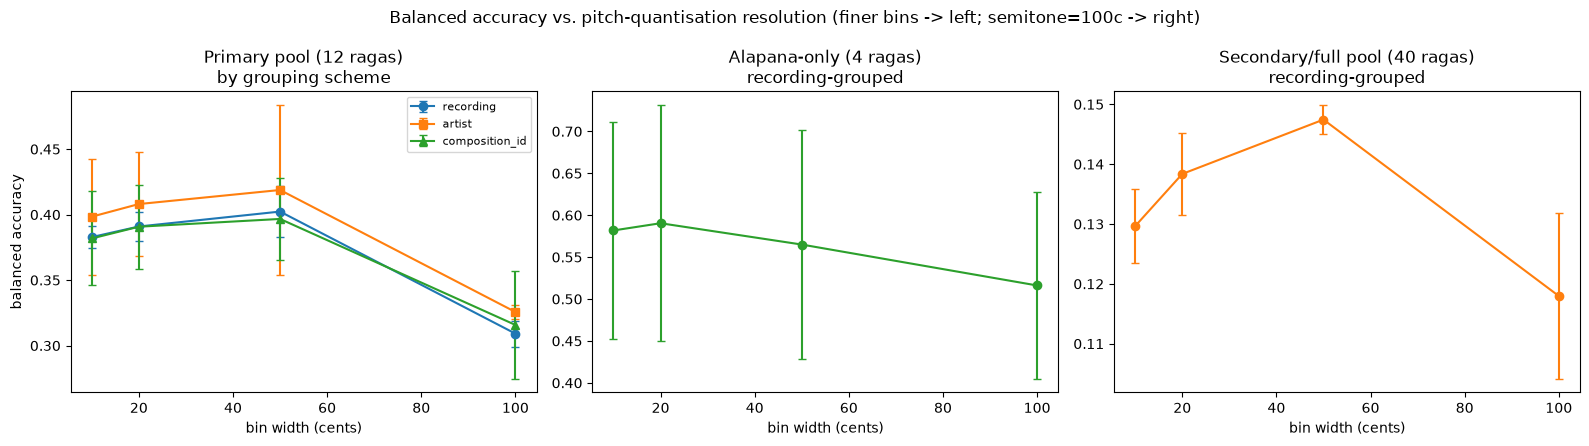

saved D:\DGM\artifacts\figures\m2_accuracy_vs_resolution.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)

ax = axes[0]
for grp, marker in [("recording","o"), ("artist","s"), ("composition_id","^")]:
    d = summary.query("corpus=='allsections' and pool=='primary12' and grouping==@grp")
    ax.errorbar(d.resolution, d.bal_acc_mean, yerr=d.bal_acc_std, marker=marker, capsize=3, label=grp)
ax.set_title("Primary pool (12 ragas)\nby grouping scheme"); ax.set_xlabel("bin width (cents)")
ax.set_ylabel("balanced accuracy"); ax.legend(fontsize=8)

ax = axes[1]
d = summary.query("corpus=='alapana'")
ax.errorbar(d.resolution, d.bal_acc_mean, yerr=d.bal_acc_std, marker="o", capsize=3, color="tab:green")
ax.set_title("Alapana-only (4 ragas)\nrecording-grouped"); ax.set_xlabel("bin width (cents)")

ax = axes[2]
d = summary.query("corpus=='allsections' and pool=='secondary40'")
ax.errorbar(d.resolution, d.bal_acc_mean, yerr=d.bal_acc_std, marker="o", capsize=3, color="tab:orange")
ax.set_title("Secondary/full pool (40 ragas)\nrecording-grouped"); ax.set_xlabel("bin width (cents)")

fig.suptitle("Balanced accuracy vs. pitch-quantisation resolution (finer bins -> left; semitone=100c -> right)")
fig.tight_layout()
outp = os.path.join(ART, "figures", "m2_accuracy_vs_resolution.png")
fig.savefig(outp, dpi=130)
plt.show()
print("saved", outp)

## 6. Per-raga degradation ranking

Generalises the allied-pair claim without needing a balance constraint: ragas whose
identity lives in gamaka should degrade hard from continuous to semitone; ragas
separable by note set alone should barely move. Computed on the primary pool,
recording-grouped, using out-of-fold predictions.

          raga  recall_continuous  recall_semitone   drop
        Suraṭi              0.441            0.271  0.170
Sindhubhairavi              0.465            0.318  0.147
       Mōhanaṁ              0.433            0.295  0.139
         Kamās              0.497            0.374  0.124
     Rītigauḷa              0.198            0.103  0.095
      Bhairavi              0.450            0.384  0.065
          Tōḍi              0.433            0.369  0.063
       Kalyāṇi              0.132            0.085  0.047
         Behāg              0.377            0.339  0.038
 Ṣanmukhapriya              0.432            0.408  0.025
  Harikāmbhōji              0.188            0.190 -0.002
        Sāvēri              0.649            0.747 -0.098


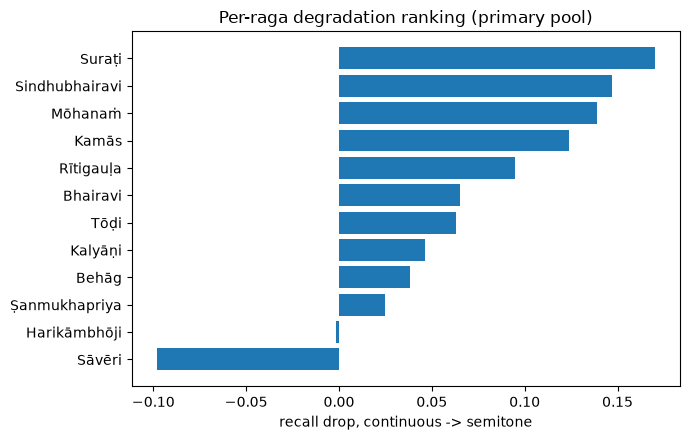

saved D:\DGM\artifacts\figures\m2_raga_degradation_ranking.png


In [8]:
y = Wp.raga.values
groups = Wp.recording.values
splitter, n_splits = U.make_group_cv(y, groups, max_splits=5)
preds = {}
for bw in [10, 100]:
    X = np.stack([U.histogram_feature(w, bw) for w in Wp.window])
    preds[bw] = cross_val_predict(LogisticRegression(**CLF_KW), X, y,
                                  cv=splitter.split(X, y, groups), n_jobs=1)

rank_rows = []
for raga in PRIMARY_POOL:
    mask = (y == raga)
    rec_cont = (preds[10][mask] == raga).mean()
    rec_semi = (preds[100][mask] == raga).mean()
    rank_rows.append(dict(raga=raga, recall_continuous=rec_cont, recall_semitone=rec_semi,
                          drop=rec_cont - rec_semi))
RANK = pd.DataFrame(rank_rows).sort_values("drop", ascending=False).reset_index(drop=True)
RANK.to_csv(os.path.join(ART, "m2_raga_degradation_ranking.csv"), index=False)
print(RANK.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(RANK.raga, RANK["drop"])
ax.set_xlabel("recall drop, continuous -> semitone"); ax.invert_yaxis()
ax.set_title("Per-raga degradation ranking (primary pool)")
fig.tight_layout()
outp = os.path.join(ART, "figures", "m2_raga_degradation_ranking.png")
fig.savefig(outp, dpi=130)
plt.show()
print("saved", outp)

## 7. Headline numbers -> `artifacts/numbers.json`

In [9]:
outp = os.path.join(ART, "numbers.json")
existing = {}
if os.path.exists(outp):
    with open(outp, encoding="utf-8") as fh: existing = json.load(fh)

def headline(corpus, pool, grouping):
    d = summary.query("corpus==@corpus and pool==@pool and grouping==@grouping").set_index("resolution")
    return {f"{U.RESOLUTION_LABELS[r]}": dict(bal_acc_mean=round(float(d.loc[r,'bal_acc_mean']),4),
                                              bal_acc_std=round(float(d.loc[r,'bal_acc_std']),4))
           for r in RESOLUTIONS if r in d.index}

existing["m2"] = {
    "window_sec": WINDOW_SEC, "hop_sec": HOP_SEC, "resolutions_cents": RESOLUTIONS,
    "classifier": "LogisticRegression(class_weight=balanced, C=10)",
    "class_imbalance_catch": "unweighted LR gave near-chance/degenerate zero-recall results on imbalanced window counts; class_weight=balanced fixed it (see section 2)",
    "primary_pool_ragas": PRIMARY_POOL,
    "secondary_pool_size": len(SECONDARY_POOL),
    "alapana_recording_grouped": headline("alapana", "all4", "recording"),
    "primary12_recording_grouped": headline("allsections", "primary12", "recording"),
    "primary12_artist_grouped": headline("allsections", "primary12", "artist"),
    "primary12_composition_grouped": headline("allsections", "primary12", "composition_id"),
    "secondary40_recording_grouped": headline("allsections", "secondary40", "recording"),
    "raga_degradation_ranking": RANK.round(4).to_dict(orient="records"),
}
with open(outp, "w", encoding="utf-8") as fh:
    json.dump(existing, fh, ensure_ascii=False, indent=2)
print("wrote", outp)
print(json.dumps(existing["m2"], ensure_ascii=False, indent=2)[:2000])

wrote D:\DGM\artifacts\numbers.json
{
  "window_sec": 4.0,
  "hop_sec": 4.0,
  "resolutions_cents": [
    10,
    20,
    50,
    100
  ],
  "classifier": "LogisticRegression(class_weight=balanced, C=10)",
  "class_imbalance_catch": "unweighted LR gave near-chance/degenerate zero-recall results on imbalanced window counts; class_weight=balanced fixed it (see section 2)",
  "primary_pool_ragas": [
    "Kamās",
    "Tōḍi",
    "Bhairavi",
    "Behāg",
    "Kalyāṇi",
    "Mōhanaṁ",
    "Suraṭi",
    "Rītigauḷa",
    "Ṣanmukhapriya",
    "Harikāmbhōji",
    "Sindhubhairavi",
    "Sāvēri"
  ],
  "secondary_pool_size": 40,
  "alapana_recording_grouped": {
    "continuous (10c)": {
      "bal_acc_mean": 0.5818,
      "bal_acc_std": 0.1292
    },
    "20c": {
      "bal_acc_mean": 0.5904,
      "bal_acc_std": 0.141
    },
    "50c": {
      "bal_acc_mean": 0.565,
      "bal_acc_std": 0.1371
    },
    "semitone (100c)": {
      "bal_acc_mean": 0.5162,
      "bal_acc_std": 0.1114
    }
  },
  "